# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

Model Performance Comparison:
                       RMSE  R2 Score
Linear Regression  0.745581  0.575788
Ridge Regression   0.745554  0.575819
Decision Tree      0.724234  0.599732


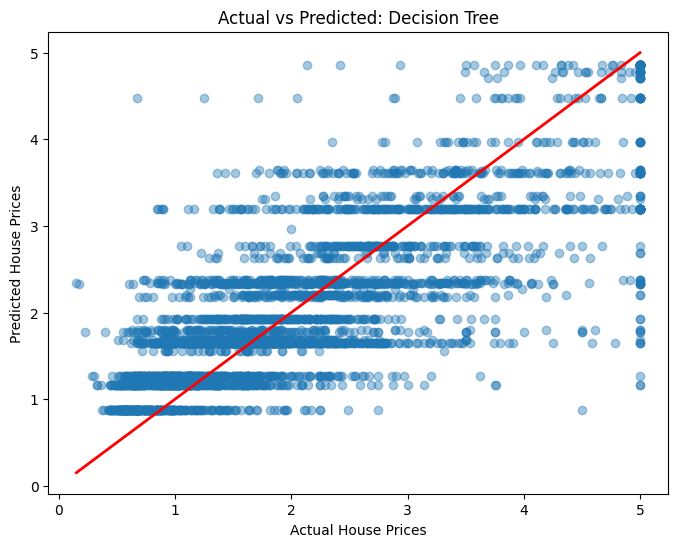


SUCCESS: The 'Decision Tree' was saved as 'best_house_price_model.pkl'.


In [3]:
# --- STEP 1: Import Required Libraries ---
# These libraries handle data manipulation, model training, evaluation, and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib  # For saving the final model
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- STEP 2: Load the Dataset ---
# We use the California Housing Dataset which contains real housing-related data.
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

# --- STEP 3: Separate Features and Target Variable ---
# ML models require input features (X) and an output variable (y) to be handled separately.
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# --- STEP 4: Feature Scaling (Critical Step) ---
# Scaling ensures fair learning across features and prevents model instability.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- STEP 5: Train-Test Split ---
# This ensures the model is evaluated using unseen data.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --- STEP 6: Train Multiple Models ---
# Training multiple algorithms allows us to compare results and select the best model.
models = {
    "Linear Regression": LinearRegression(),           # Baseline model [cite: 105]
    "Ridge Regression": Ridge(alpha=1.0),              # Reduces overfitting [cite: 106]
    "Decision Tree": DecisionTreeRegressor(max_depth=5) # Captures non-linear relationships
}

# --- STEP 7: Model Evaluation and Comparison ---
# Lower RMSE indicates better accuracy, while higher R2 indicates better explanatory power.
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # Manual RMSE calculation to avoid version-specific keyword errors
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)
    results[name] = {"RMSE": rmse, "R2 Score": r2}

# Create the performance comparison table
results_df = pd.DataFrame(results).T
print("Model Performance Comparison:")
print(results_df)

# --- STEP 8: Visual Performance Validation ---
# A closer alignment of points to the red reference line indicates better performance.
# Pick the best performing model based on R2 Score for visualization
best_model_name = results_df['R2 Score'].idxmax()
best_model = models[best_model_name]
y_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", lw=2)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.show()

# --- STEP 9: Save the Best Model (Additional Section) ---
# Saving the best-performing model using joblib for future deployment.
joblib.dump(best_model, 'best_house_price_model.pkl')
print(f"\nSUCCESS: The '{best_model_name}' was saved as 'best_house_price_model.pkl'.")